In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [4]:
category = "bottle"

DATA_PATH = f"Data/mvtec/{category}/train/good"
TEST_PATH = f"Data/mvtec/{category}/test"

In [5]:
category = "bottle"

DATA_PATH = f"Data/mvtec/{category}/train/good"
TEST_PATH = f"Data/mvtec/{category}/test"

In [6]:
DATA_PATH = r"C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\train\good"

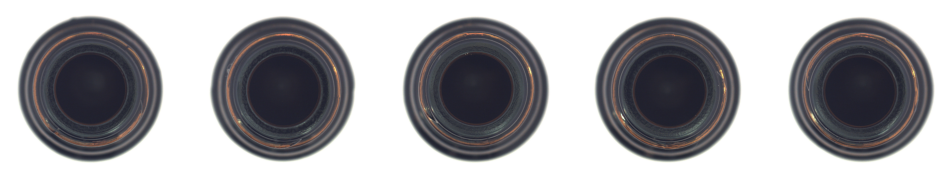

In [7]:
images = os.listdir(DATA_PATH)

plt.figure(figsize=(12,4))

for i in range(5):
    
    img_path = os.path.join(DATA_PATH, images[i])
    img = Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [8]:
transform = transforms.Compose([
    
    transforms.Resize((256,256)),
    transforms.ToTensor()

])

In [9]:
class MVTecDataset(Dataset):
    
    def __init__(self, root_dir, transform=None):
        
        self.root_dir = root_dir
        self.image_paths = [
            os.path.join(root_dir, img)
            for img in os.listdir(root_dir)
        ]
        
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image

In [10]:
dataset = MVTecDataset(
    root_dir=DATA_PATH,
    transform=transform
)

print("Total images:", len(dataset))

Total images: 209


In [11]:
sample = dataset[0]

print(sample.shape)

torch.Size([3, 256, 256])


In [12]:
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

In [13]:
batch = next(iter(dataloader))

print(batch.shape)

torch.Size([16, 3, 256, 256])


In [14]:
import torch

if torch.cuda.is_available():
    print("GPU is available")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU is available
GPU Name: NVIDIA GeForce RTX 3060


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [16]:
print(torch.cuda.get_device_name(0))
print("Allocated:", torch.cuda.memory_allocated(0)/1024**3, "GB")
print("Cached:", torch.cuda.memory_reserved(0)/1024**3, "GB")

NVIDIA GeForce RTX 3060
Allocated: 0.0 GB
Cached: 0.0 GB


In [17]:
import torch

x = torch.randn(3,3).to(device)
print(x.device)

cuda:0


In [18]:
import torch
import torch.nn as nn

In [19]:
class Autoencoder(nn.Module):
    
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            
            nn.Conv2d(3, 32, 3, stride=2, padding=1),   # 256 → 128
            nn.ReLU(),
            
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 128 → 64
            nn.ReLU(),
            
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 64 → 32
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # 32 → 64
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 64 → 128
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),   # 128 → 256
            nn.Sigmoid()
        )
        
    def forward(self, x):
        
        x = self.encoder(x)
        x = self.decoder(x)
        
        return x

In [20]:
model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)


In [21]:
batch = next(iter(dataloader))
batch = batch.to(device)

output = model(batch)

print("Input shape:", batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 3, 256, 256])


In [22]:
import torch.optim as optim
from tqdm import tqdm

In [23]:
criterion = nn.MSELoss()

difference between original image and reconstructed image

In [24]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [25]:
num_epochs = 100

In [26]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epoch_losses = []   # store loss values

for epoch in range(num_epochs):

    running_loss = 0

    for images in tqdm(dataloader):

        images = images.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, images)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    epoch_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss}")

100%|██████████| 14/14 [00:07<00:00,  1.79it/s]


Epoch 1, Loss: 0.12607766741088458


100%|██████████| 14/14 [00:03<00:00,  3.91it/s]


Epoch 2, Loss: 0.05487386616212981


100%|██████████| 14/14 [00:04<00:00,  3.48it/s]


...

Epoch 98, Loss: 0.0003923777528273474


100%|██████████| 14/14 [00:04<00:00,  3.50it/s]


Epoch 99, Loss: 0.00040178205693207147


100%|██████████| 14/14 [00:03<00:00,  3.68it/s]

Epoch 100, Loss: 0.0003908121122679274


In [27]:
torch.save(model.state_dict(), "autoencoder_bottle.pth")

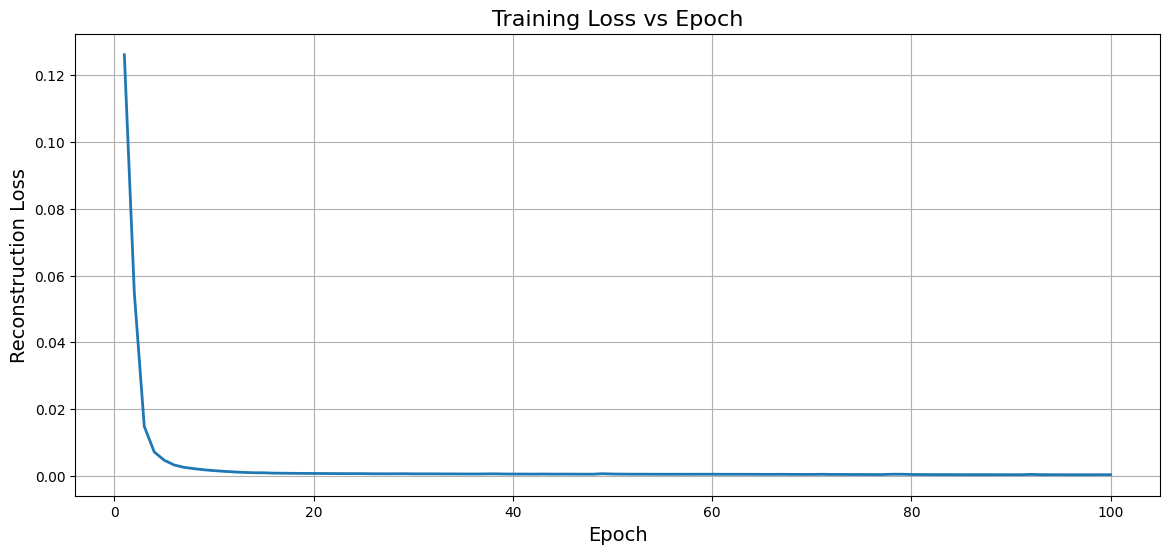

In [28]:
epochs = range(1, len(epoch_losses)+1)

plt.figure(figsize=(14,6))
plt.plot(epochs, epoch_losses, linewidth=2)

plt.title("Training Loss vs Epoch", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Reconstruction Loss", fontsize=14)

plt.grid(True)

plt.show()

In [29]:
plt.savefig("training_loss_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [30]:
TEST_PATH = r"C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test"

In [31]:
import os
from PIL import Image

test_images = []

for defect_type in os.listdir(TEST_PATH):

    folder = os.path.join(TEST_PATH, defect_type)

    for img in os.listdir(folder)[:2]:   # take 2 images per category
        
        path = os.path.join(folder, img)
        test_images.append(path)

In [32]:
import cv2
print(cv2.__version__)

4.13.0


In [33]:
import sys
print(sys.executable)

c:\Users\ADMIN\anaconda3\envs\torch-gpu\python.exe


In [34]:
!pip install opencv-python

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [35]:
import torch.nn.functional as F
import cv2
import numpy as np

def generate_anomaly_map(model, image_path):

    model.eval()

    img = Image.open(image_path).convert("RGB")

    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        reconstruction = model(img_tensor)

    # compute reconstruction error
    error = torch.abs(img_tensor - reconstruction)

    # average across RGB channels
    error_map = torch.mean(error, dim=1).squeeze().cpu().numpy()

    return img, error_map

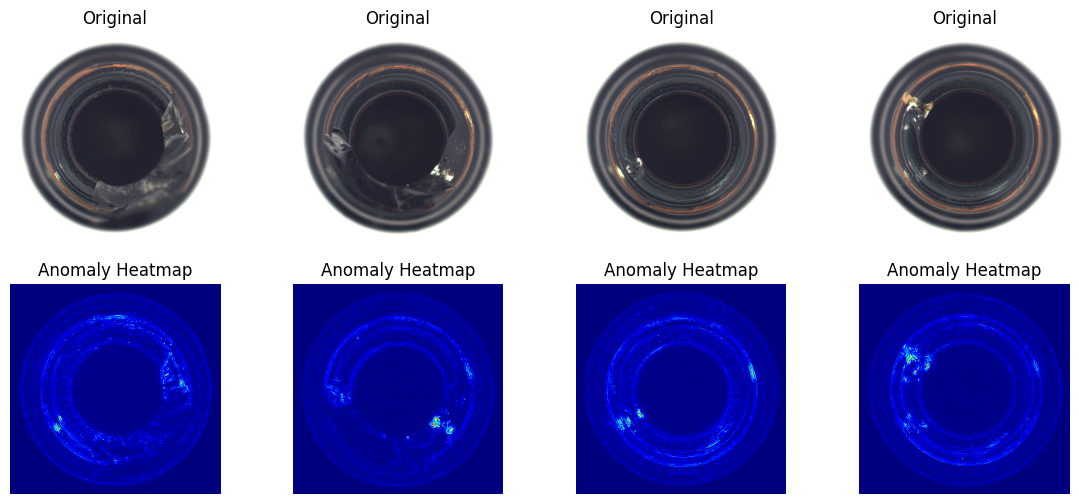

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

for i, img_path in enumerate(test_images[:4]):

    original, anomaly_map = generate_anomaly_map(model, img_path)

    # normalize values between 0 and 1
    anomaly_map = (anomaly_map - anomaly_map.min()) / (anomaly_map.max() - anomaly_map.min())

    plt.subplot(2,4,i+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(anomaly_map, cmap="jet")
    plt.title("Anomaly Heatmap")
    plt.axis("off")

plt.show()

In [37]:
import cv2

def overlay_heatmap(original_img, anomaly_map):

    anomaly_map = cv2.resize(anomaly_map, original_img.size)

    heatmap = cv2.applyColorMap((anomaly_map*255).astype(np.uint8), cv2.COLORMAP_JET)

    original_np = np.array(original_img)

    overlay = cv2.addWeighted(original_np, 0.6, heatmap, 0.4, 0)

    return overlay

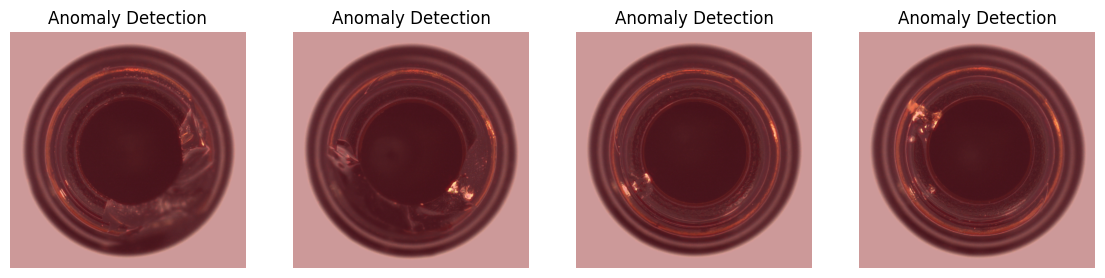

In [38]:
plt.figure(figsize=(14,5))

for i, img_path in enumerate(test_images[:4]):

    original, anomaly_map = generate_anomaly_map(model, img_path)

    overlay = overlay_heatmap(original, anomaly_map)

    plt.subplot(1,4,i+1)
    plt.imshow(overlay)
    plt.title("Anomaly Detection")
    plt.axis("off")

plt.show()

In [39]:
plt.imsave("example_anomaly_result.png", overlay)

In [40]:
def compute_anomaly_score(anomaly_map):
    
    score = np.mean(anomaly_map)
    
    return score

In [41]:
for img_path in test_images[:4]:

    original, anomaly_map = generate_anomaly_map(model, img_path)

    score = compute_anomaly_score(anomaly_map)

    print("Image:", img_path)
    print("Anomaly Score:", score)
    print("--------------")

Image: C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test\broken_large\000.png
Anomaly Score: 0.009063342
--------------
Image: C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test\broken_large\001.png
Anomaly Score: 0.008832991
--------------
Image: C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test\broken_small\000.png
Anomaly Score: 0.010524473
--------------
Image: C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test\broken_small\001.png
Anomaly Score: 0.010707577
--------------


In [56]:
threshold = 0.0105

In [57]:
for img_path in test_images[:4]:

    original, anomaly_map = generate_anomaly_map(model, img_path)

    score = compute_anomaly_score(anomaly_map)

    label = "Defective" if score > threshold else "Normal"

    print(f"Score: {score:.4f} → {label}")

Score: 0.0091 → Normal
Score: 0.0088 → Normal
Score: 0.0105 → Defective
Score: 0.0107 → Defective


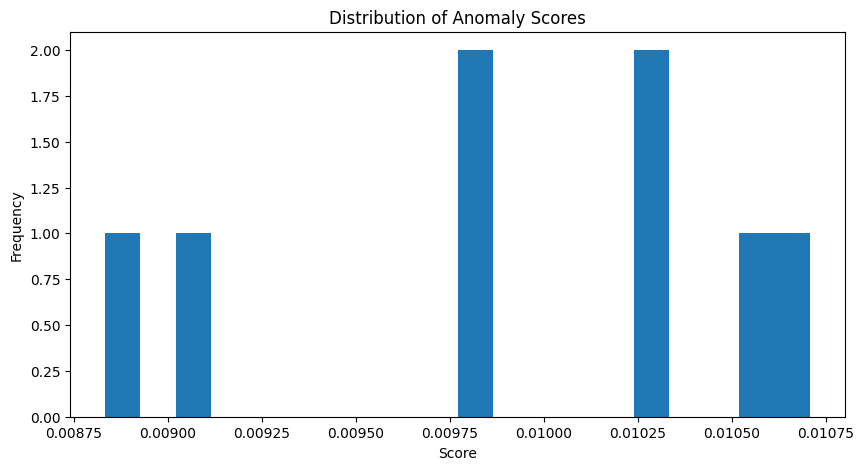

In [58]:
scores = []

for img_path in test_images:

    _, anomaly_map = generate_anomaly_map(model, img_path)

    score = compute_anomaly_score(anomaly_map)

    scores.append(score)

plt.figure(figsize=(10,5))

plt.hist(scores, bins=20)

plt.title("Distribution of Anomaly Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

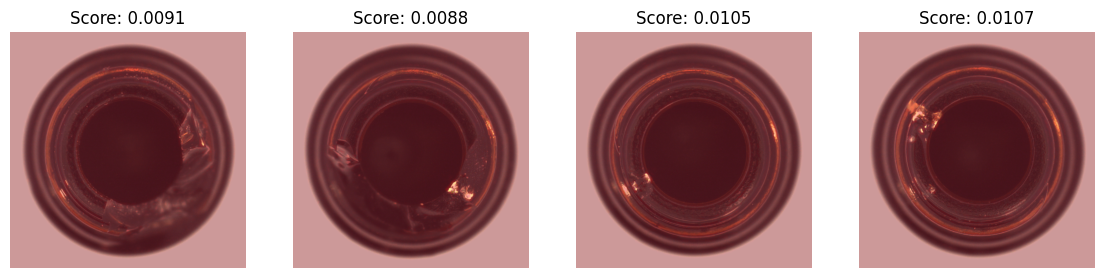

In [59]:
plt.figure(figsize=(14,5))

for i, img_path in enumerate(test_images[:4]):

    original, anomaly_map = generate_anomaly_map(model, img_path)

    score = compute_anomaly_score(anomaly_map)

    overlay = overlay_heatmap(original, anomaly_map)

    plt.subplot(1,4,i+1)
    plt.imshow(overlay)
    plt.title(f"Score: {score:.4f}")
    plt.axis("off")

plt.show()

In [60]:
def create_defect_mask(anomaly_map, pixel_threshold=0.02):

    mask = anomaly_map > pixel_threshold

    return mask

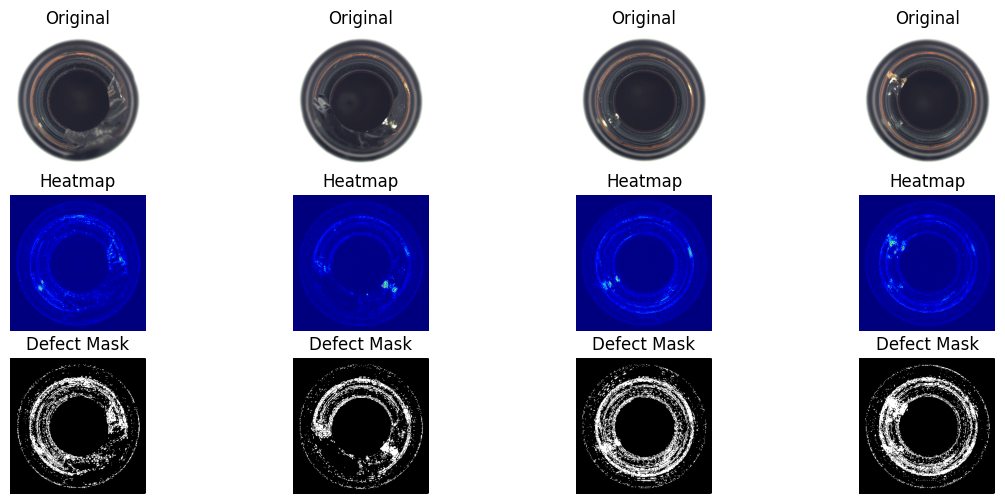

In [61]:
plt.figure(figsize=(14,6))

for i, img_path in enumerate(test_images[:4]):

    original, anomaly_map = generate_anomaly_map(model, img_path)

    mask = create_defect_mask(anomaly_map)

    plt.subplot(3,4,i+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,4,i+5)
    plt.imshow(anomaly_map, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(3,4,i+9)
    plt.imshow(mask, cmap="gray")
    plt.title("Defect Mask")
    plt.axis("off")

plt.show()

In [62]:
def overlay_mask(original_img, mask):

    img = np.array(original_img)

    img[mask] = [255, 0, 0]

    return img

In [63]:
def overlay_mask(original_img, mask):

    img = np.array(original_img)

    # resize mask to original image size
    mask_resized = cv2.resize(mask.astype(np.uint8),
                              (img.shape[1], img.shape[0]))

    mask_resized = mask_resized.astype(bool)

    img[mask_resized] = [255, 0, 0]

    return img

(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

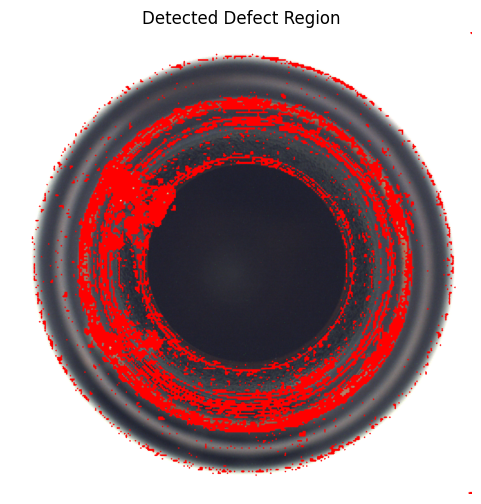

In [64]:
overlay = overlay_mask(original, mask)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Detected Defect Region")
plt.axis("off")

In [65]:
print(original.size)      # PIL image size
print(anomaly_map.shape)  # numpy map size

(900, 900)
(256, 256)


In [66]:
def smooth_anomaly_map(anomaly_map):

    smoothed = cv2.GaussianBlur(anomaly_map, (11,11), 0)

    return smoothed

In [67]:
smoothed_map = smooth_anomaly_map(anomaly_map)

mask = create_defect_mask(smoothed_map)

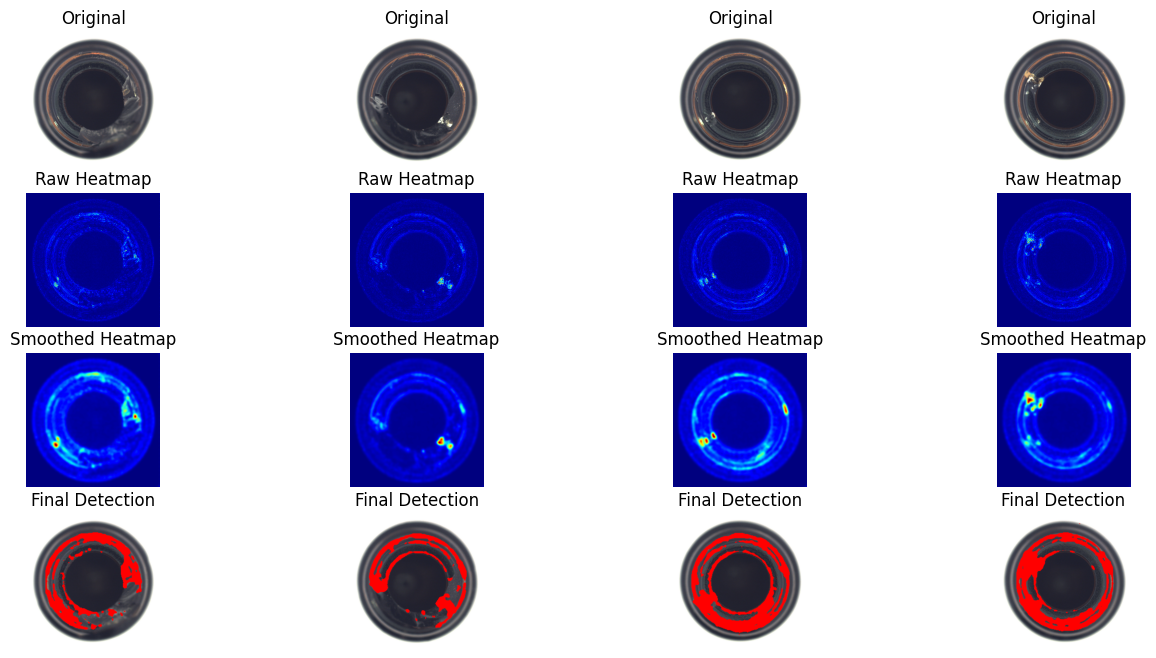

In [68]:
plt.figure(figsize=(16,8))

for i, img_path in enumerate(test_images[:4]):

    original, anomaly_map = generate_anomaly_map(model, img_path)

    smoothed_map = smooth_anomaly_map(anomaly_map)

    mask = create_defect_mask(smoothed_map)

    overlay = overlay_mask(original, mask)

    # original
    plt.subplot(4,4,i+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    # raw heatmap
    plt.subplot(4,4,i+5)
    plt.imshow(anomaly_map, cmap="jet")
    plt.title("Raw Heatmap")
    plt.axis("off")

    # smoothed heatmap
    plt.subplot(4,4,i+9)
    plt.imshow(smoothed_map, cmap="jet")
    plt.title("Smoothed Heatmap")
    plt.axis("off")

    # final detection
    plt.subplot(4,4,i+13)
    plt.imshow(overlay)
    plt.title("Final Detection")
    plt.axis("off")

plt.show()

In [70]:
import sys
import os 

sys.path.append(r"C:\Users\ADMIN\Documents\CV_Proj")

In [71]:
import glob
import os
from backend.inference import run_patchcore

good_path = r"C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test\good"
image_paths = glob.glob(os.path.join(good_path, "*.png"))

scores = []

for img in image_paths[:20]:
    _, s = run_patchcore("bottle", img)
    scores.append(s)

print("Min:", min(scores))
print("Max:", max(scores))
print("Avg:", sum(scores)/len(scores))

Min: 2.1883633136749268
Max: 2.2934584617614746
Avg: 2.23267205953598


In [72]:
for img_path in test_images:
    heatmap, score = run_patchcore("bottle", img_path)

    label = "Defect" if score > 0.0105 else "Normal"
    print(score, label)

2.996185302734375 Defect
3.323489189147949 Defect
2.864288330078125 Defect
3.2307963371276855 Defect
2.5816338062286377 Defect
2.47804856300354 Defect
2.1978225708007812 Defect
2.236412286758423 Defect


In [73]:
threshold = sum(scores)/len(scores)
print("Threshold:", threshold)

Threshold: 2.23267205953598


In [75]:
for img in image_paths[:10]:
    _, s = run_patchcore("bottle", img)
    label = "Defect" if s > 2.25 else "Normal"
    print(s, label)

2.1978225708007812 Normal
2.236412286758423 Normal
2.2646396160125732 Defect
2.2001795768737793 Normal
2.223370313644409 Normal
2.22104549407959 Normal
2.2613048553466797 Defect
2.2194528579711914 Normal
2.2371151447296143 Normal
2.2173779010772705 Normal


In [76]:
scores = []

for img in image_paths[:20]:
    _, s = run_patchcore("bottle", img)
    scores.append(s)
print(min(scores), max(scores))

2.1883633136749268 2.2934584617614746
